In [10]:
import pandas as pd
# load cytof
df = pd.read_csv('./data/cytof.csv', index_col=0)
# subset to pAKT and pS6
df = df[df['observableId'].isin(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6'])]
df['preequilibrationConditionId'] = df['preequilibrationConditionId'].apply(lambda x: x[1:])
# subset to cell lines (exclude full media conditions)
cell_lines = [c for c in df['preequilibrationConditionId'].unique() if not c.endswith('full')]
df = df[df['preequilibrationConditionId'].isin(cell_lines)]
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
# subset to EGF, iPI3K
df = df[df['treatment'].isin(['EGF', 'iPI3K'])]

# load annotations
annotation = pd.read_csv('./cell_line_subtypes.txt', index_col=0, sep='\t')
# map to lineage
df['lineage'] = df['preequilibrationConditionId'].apply(
    lambda x: {
        "LuminalA": 'luminal',
        "LuminalB": 'luminal',
        "HER2": 'luminal',
        "Basal": 'basal',
        "CL": 'basal',
        "Normal": 'normal'
    }.get(annotation.loc[x.lower().replace('mpe600','600mpe'), 'subtype_intrinsic']))

# count number of non-nan measurements per group
df['isna'] = df['measurement'].isna().astype('float') + 1

df = df[df['lineage'] != 'normal']

df['treatment'] = df['treatment'].replace('iPI3K', 'EGF + pictilisib')


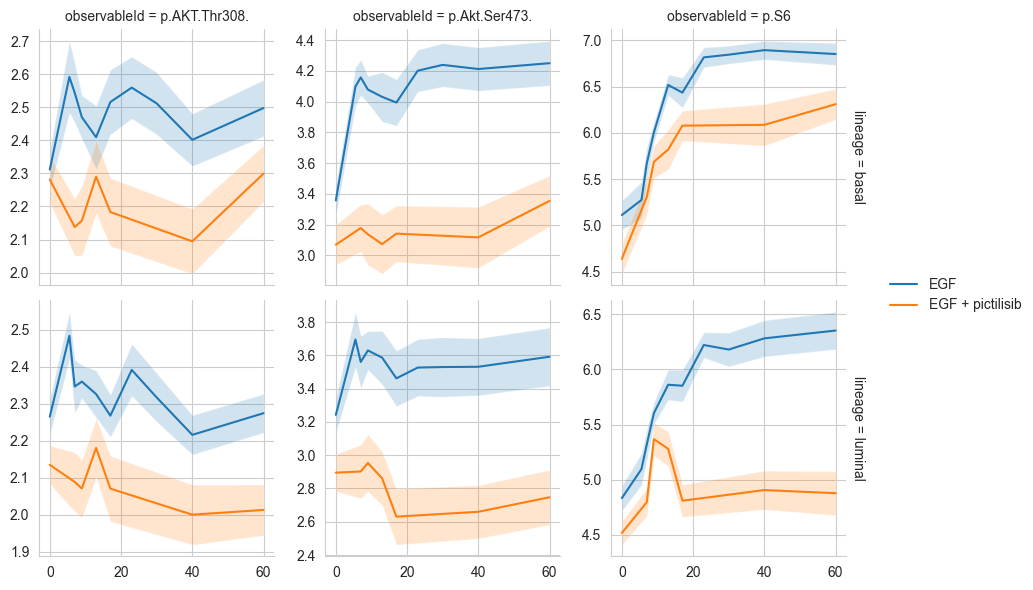

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# aggregate mean and std per lineage
dfp = (
    df[['treatment', 'time', 'observableId', 'lineage', 'measurement', 'isna']]
    .groupby(['treatment', 'time', 'observableId', 'lineage'])
    .agg(measurement_mean=('measurement', 'mean'),
         measurement_std=('measurement', 'std'),
         n=('measurement', 'count'),
         isna=('isna', 'sum'))
    .reset_index()
)

dfp['measurement_se'] = dfp['measurement_std'] / np.sqrt(dfp['n'])

# filter data
dfp_filtered = dfp[dfp['isna'] >= 4]

# create FacetGrid
g = sns.FacetGrid(
    data=dfp_filtered,
    row="lineage",
    col="observableId",
    margin_titles=True,
    sharey=False,
)

# map lineplots
def plot_with_shading(data, **kwargs):
    ax = plt.gca()
    for treatment, subdf in data.groupby("treatment"):
        ax.plot(subdf["time"], subdf["measurement_mean"], label=treatment)
        ax.fill_between(
            subdf["time"],
            subdf["measurement_mean"] - subdf["measurement_se"],
            subdf["measurement_mean"] + subdf["measurement_se"],
            alpha=0.2
        )

g.map_dataframe(plot_with_shading)
g.add_legend()